<a href="https://colab.research.google.com/github/christianlee479/CPSC-2200/blob/main/CPSC_2200_DLP_chapter04_classification_and_regression(ChristianLee).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yale University


# CPSC 2200 Introduction to Data Analysis and Machine Learning for Humanities and Social Sciences

**Instructor**: Sohee Park

**TF**: George Typaldos

**ULA**: Kenneth Shui

Department of Computer Science

This is a notebook generated for CPSC 2200, a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

## Learning Objectives:

This module covers
* Your first examples of real-world machine
learning workflows
* Handling binary and categorical classification
problems
* Handling continuous regression problems

In [1]:
!pip install keras keras-hub==0.21.1 --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.0 MB/s eta 0:00:00


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Important Glossary

- Sample/Input: Data point as input to your model
- Prediction/Output: The output of your model
- Target: The groundtruth -- correct predictions according to your data
- Prediction Error/Loss value: Measure of distance between model prediction and target
- Classes: Set of possible labels in a classification problem
- Label: Class annotation
- Ground-truth/Annotations: All targets for a dataset
- Binary Classification: Classification task where each input sample is categorized into two categories
- Category/Multiclass Classification: Classification task where each input sample is categorized into more than two categories
- Multilabel Classification: Classification task where each input sample can be assigned multiple labels
- Scalar Regression: Task where the target is a continuous scalar value (e.g. prices of a house)
- Vector Regression: Task where the target is a set of continous values, e.g. continuous vector
- Mini-batch/batch: Small set of samples that are processed simultaneously by the model

### Classifying movie reviews: A binary classification example

We are going to inspect an imdb dataset with movie reviews and classify these reviews into positive or negative (binary classification) based on the text content of the reviews.

#### The IMDb dataset

A set of 50,000 highly polarized reviews split into 25,000 reviews for training and 25,000 for testing.
Each set consists of 50% negative and 50% positive reviews.

In [4]:
from keras.datasets import imdb

# We keep only the 10,000 most frequently occuring words in the training data
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [6]:
train_labels[0]

np.int64(1)

In [7]:
max([max(sequence) for sequence in train_data])

9999

In [8]:
# Decode one of the reviews into English

# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
# Reverses it, mapping integer indices to words.
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# Decodes the reivew of the first training data.
# NOTE) The indices are off set by 3, # because 0, 1, 2 are reserved indices
# for "padding," "start of sequence," and "unknown"
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
# check the first 100 characters.  decoded_view is a string.
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

We perform multi-hot encoding to turn our lists into 0s and 1s, reflecting the presence or absence of all possible words.

In [10]:
import numpy as np

# Creates an all-zero matrix of shape (len(sequeneses), num_classes)
def multi_hot_encode(sequences, num_classes):
    # sequence is a list of indicies
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        # Sets specific indices of results[i] to 1s
        results[i][sequence] = 1.0
    return results

# vectorize train_data with 10000 classes
x_train = multi_hot_encode(train_data, 10000)      # Vectorized training data
# vectorize test_data with 10000 classes
x_test =  multi_hot_encode(test_data, 10000) #       # Vectorized test data

In [11]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [12]:
# also vectorize labels by converting the type from ints to floats
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [13]:
import keras
from keras import layers

# Create a keras.Sequential model with:
# 2 16-size Dense layers with 'relu' activation
# 1 1-size Dense layer with 'sigmoid' activation
model =  keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [14]:
# Compile model with:
# 'adam' optimizer
# 'binary_crossentropy' loss
# 'accuracy' metrics
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

In [15]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [16]:
# fit model with x/y_train
# use 20 epochs
# use 512 batch size
# use 0.2 validation_split
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
    )

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7611 - loss: 0.5524 - val_accuracy: 0.8700 - val_loss: 0.3854
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9049 - loss: 0.2864 - val_accuracy: 0.8912 - val_loss: 0.2829
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9348 - loss: 0.1944 - val_accuracy: 0.8928 - val_loss: 0.2754
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.1511 - val_accuracy: 0.8878 - val_loss: 0.2916
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9618 - loss: 0.1243 - val_accuracy: 0.8880 - val_loss: 0.3093
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9702 - loss: 0.1003 - val_accuracy: 0.8824 - val_loss: 0.3428
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9753 - loss: 0.0855 - val_accuracy: 0.8818 - val_loss: 0.3604
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.0684 - val_accuracy: 0.8802 - v

In [17]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

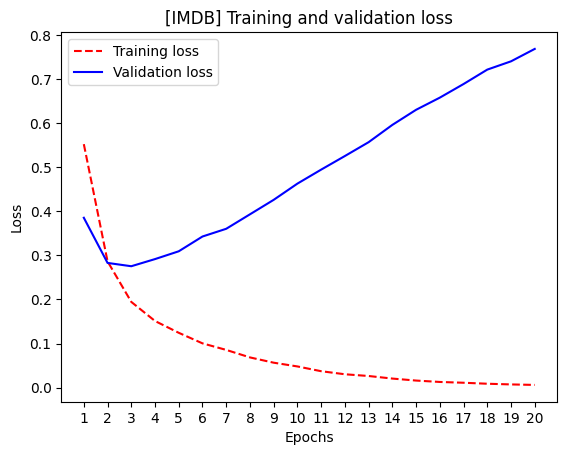

In [18]:
import matplotlib.pyplot as plt

# get model training history
history_dict = history.history
# get training loss history
loss_values = history_dict["loss"]
# get validation loss history
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
# plot training loss with red dashed line
plt.plot(epochs, loss_values, "r--", label="Training loss")
# plot validation loss with blue line
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

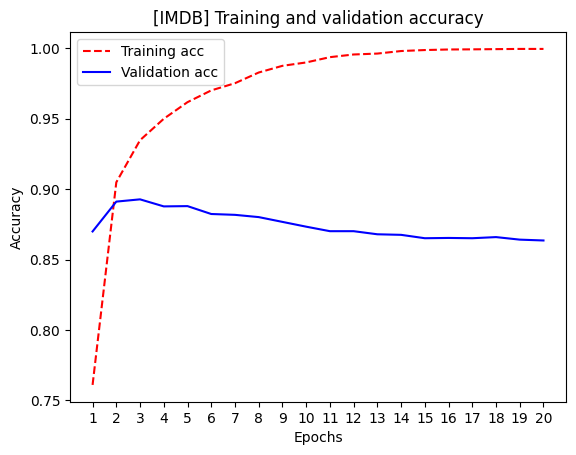

In [19]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Analyzing Training & Validation Loss

The training loss decreases with every epoch, and the training accuracy increases with every epoch.
This is expected when running gradient-descent optimization.
The validation loss and accuracy, however, seem to peak at the fourth epoch.
This is an example of a model that performs better on the training data and does not perform better on data it has never seen before.
Ane example of overfitting, as after the fourth epoch, we are overoptimizing on the training data, and end up learning representations that are specific to them and don't generalize to data outside of the training set.

So, let's try treduce the number of epochs.

In [20]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=512,
    validation_split=0.2
)
results = model.evaluate(x_test, y_test)

Epoch 1/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7930 - loss: 0.5128 - val_accuracy: 0.8654 - val_loss: 0.3644
Epoch 2/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9023 - loss: 0.2781 - val_accuracy: 0.8880 - val_loss: 0.2885
Epoch 3/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9312 - loss: 0.1998 - val_accuracy: 0.8912 - val_loss: 0.2713
Epoch 4/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9478 - loss: 0.1561 - val_accuracy: 0.8898 - val_loss: 0.2818
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8816 - loss: 0.2980


In [ ]:
results

[0.29690077900886536, 0.8831999897956848]

#### Using a trained model to generate predictions on new data

In [21]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.27039337],
       [0.9999219 ],
       [0.7059964 ],
       ...,
       [0.11996701],
       [0.12593666],
       [0.43656301]], dtype=float32)

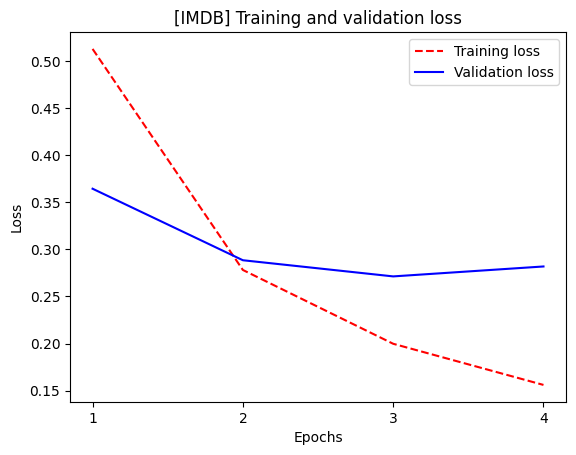

In [22]:
import matplotlib.pyplot as plt

# get model training history
history_dict = history.history
# get training loss history
loss_values = history_dict["loss"]
# get validation loss history
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
# plot training loss with red dashed line
plt.plot(epochs, loss_values, "r--", label="Training loss")
# plot validation loss with blue line
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Wrapping up

- Preprocessing on raw data is needed to be able to feed it — as tensors — into a neural network. Sequences of words can be encoded as binary vectors, but there are other encoding options, too.

- Stacks of Dense layers with relu activations can solve a wide range of problems (including sentiment classification), and you'll use them frequently.

- In a binary classification problem (two output classes), your model should end with a Dense layer with one unit and a sigmoid activation: the output of your model should be a scalar between 0 and 1, encoding a probability.

- With such a scalar sigmoid output on a binary classification problem, the loss function you should use is binary_crossentropy.

- The adam optimizer is generally a good enough choice, whatever your problem.

- As they get better on their training data, neural networks eventually start overfitting and end up obtaining increasingly worse results on data they've never seen before. Be sure to always monitor performance on data that is outside of the training set!

### Classifying newswires: A multiclass classification example

In this section, you'll build a model to classify Reuters newswires into 46 mutually exclusive topics. Because you have many classes, this problem is an instance of multiclass classification, and because each data point should be classified into only one category, the problem is more specifically an instance of single-label, multiclass classification. If each data point could belong to multiple categories (in this case, topics), you'd be facing a multilabel, multiclass classification problem

#### The Reuters dataset

A set of short newswires and their topics, published by Reuters in 1986. There are 46 different topics; some topics are more represented than others, but each topic has at least 10 examples in the training set.

In [44]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [29]:
len(train_data)

8982

In [30]:
len(test_data)

2246

In [31]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

Let's decode one back into words

In [32]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [33]:
decoded_newswire


'? period ended december 31 shr profit 11 cts vs loss 24 cts net profit 224 271 vs loss 511 349 revs 7 258 688 vs 7 200 349 reuter 3'

In [34]:
train_labels[10]

np.int64(3)

#### Preparing the data

We vectorize the data with the exact same code as in the previous example.

In [36]:
# use multi_hot_encode with 10000 classes
x_train = multi_hot_encode(train_data, 10000)
x_test = multi_hot_encode(test_data, 10000)

To vectorize the labels, there are two possibilities: you can leave the labels untouched as integers, or you can use one-hot encoding.
One-hot encoding is a widely used format for categorical data, also called categorical encoding. In this case, one-hot encoding of the labels consists of embedding each label as an all-zero vector with a 1 in the place of the label index.

In [37]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

# transform train_labels with one_hot_encode
y_train = one_hot_encode(train_labels)
# transform test_labels with one_hot_encode
y_test = one_hot_encode(test_labels)

In [38]:
from keras.utils import to_categorical

# instead of manual implementing one_hot_encode
# we can directly use the respective keras function
y_train = to_categorical(train_labels, num_classes=46)
y_test = to_categorical(test_labels, num_classes=46)

#### Building your model

In the previous example, you used 16-dimensional intermediate layers, but a 16-dimensional space may be too limited to learn to separate 46 different classes: such small layers may act as information bottlenecks, permanently dropping relevant information.

For this reason, you'll use larger intermediate layers.

In [40]:
# Create a keras Sequential model with:
# 2 Dense layers with 64 units and 'relu' activation
# Final Dense layer with 46 units (46 output classes) and 'softmax' activation
model = keras.Sequential(
    [
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(46, activation='softmax'),
    ]
)

The best loss function to use in this case is categorical_crossentropy. It measures the distance between two probability distributions — here, between the probability distribution outputted by the model and the true distribution of the labels. By minimizing the distance between these two distributions, you train the model to output something as close as possible to the true labels.

In [41]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    # use metrics 'accuracy' and
    # 'top_3_accuracy#
    metrics=['accuracy', top_3_accuracy],
)

#### Validating your approach

In [43]:
# Use first 1000 x-traininng samples as validation
x_val = x_train[:1000]
# Use the rest for training
partial_x_train = x_train[1000:]
# Same with y-train
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [45]:
# fit the model with:
# epochs: 20
# batch_size: 512
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.4321 - loss: 3.3150 - top_3_accuracy: 0.5386 - val_accuracy: 0.5410 - val_loss: 2.6291 - val_top_3_accuracy: 0.6290
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5986 - loss: 2.0561 - top_3_accuracy: 0.7156 - val_accuracy: 0.6390 - val_loss: 1.6695 - val_top_3_accuracy: 0.7530
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7101 - loss: 1.3728 - top_3_accuracy: 0.8182 - val_accuracy: 0.7140 - val_loss: 1.3037 - val_top_3_accuracy: 0.8280
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7838 - loss: 1.0337 - top_3_accuracy: 0.8687 - val_accuracy: 0.7650 - val_loss: 1.1331 - val_top_3_accuracy: 0.8520
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8300 - loss: 0.8144 - top_3_accuracy: 0.9109 - val_accuracy: 0.7890 - val_loss: 1.0331 - val_top_3_accuracy: 0.8800
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8641 - loss: 0.6417 - top_3_a

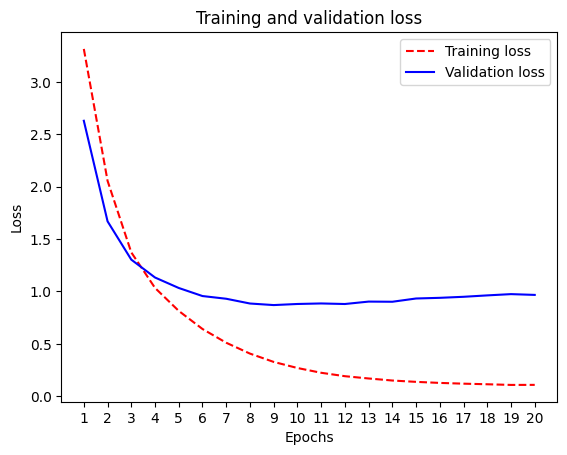

In [46]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

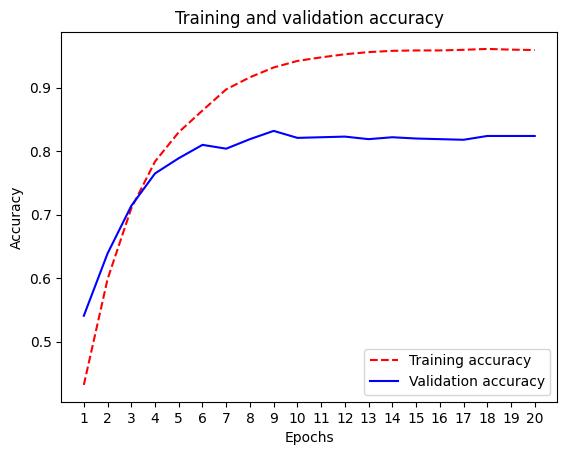

In [47]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

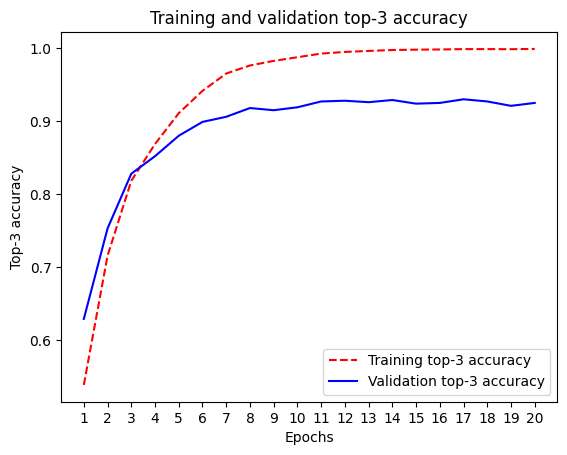

In [48]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

#### Analyzing training and validation loss

The model begins to overfit after ~ nine epochs.
So, let's train a new modelfor nine epochs and then evaluate it on the test set.

In [49]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4967 - loss: 3.0848
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6575 - loss: 1.7383
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7522 - loss: 1.1921
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8117 - loss: 0.9174
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8546 - loss: 0.7108
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8888 - loss: 0.5449
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9120 - loss: 0.4215
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9285 - loss: 0.3329
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9411 - loss: 0.2662
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7965 - loss: 0.9169


In [50]:
results

[0.9168763160705566, 0.7965272068977356]

This approach reaches an accuracy of approximately 80%. With a balanced binary classification problem, the accuracy reached by a purely random classifier would be 50%. But in this case, we have 46 classes, and they may not be equally represented. What would be the accuracy of a random baseline? We could try quickly implementing one to check this empirically:

In [51]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.19679430097951914)

A random classifier would score around 18% classification accuracy, so the results of our model seem pretty good in that light.

#### Generating predictions on new data

Calling the model's predict method on new samples returns a class probability distribution over all 46 topics for each sample.

In [52]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [53]:
predictions[0].shape

(46,)

In [54]:
np.sum(predictions[0])

np.float32(0.9999999)

In [55]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [56]:
# Leave the tensors untouched as integer vectors
y_train = train_labels
y_test = test_labels

The loss function used before, **categorical_crossentropy**, expects the labels to follow a categorical encoding.
With integer labels, you should use **sparse_categorical_crossentropy**

In [57]:
# Compile the above defined model with:
# optimizer: adam
# loss: sparse_categorical_crossentropy
# metrics: accuracy
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

Because the final outputs are 46-dimensional, you should avoid intermediate layers with much fewer than 46 units.

Let's see what happens when you introduce an information bottleneck by having intermediate layers that are significantly less than 46-dimensional

In [58]:
# Create a keras.Sequential model with:
# 1 64-size Dense layers with 'relu' activation
# 1 4-size Dense layers with 'relu' activation
# 1 46-size Dense layer with 'softmax' activation
model = keras.Sequential(
    [
        layers.Dense(64, activation='relu'),
        layers.Dense(4, activation='relu'),
        layers.Dense(46, activation='softmax')
    ]
)

# Compile model with:
# 'adam' optimizer
# 'categorical_crossentropy' loss
# 'accuracy' metrics
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fit model with:
# partial_x_train and partial_y_train
# 20 epochs, 128 batch_size
# validation data x_val, y_val
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4381 - loss: 3.4367 - val_accuracy: 0.5530 - val_loss: 2.9872
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5070 - loss: 2.6781 - val_accuracy: 0.3460 - val_loss: 2.5303
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4301 - loss: 2.0251 - val_accuracy: 0.6890 - val_loss: 1.6436
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7526 - loss: 1.1262 - val_accuracy: 0.6980 - val_loss: 1.2899
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7815 - loss: 0.9325 - val_accuracy: 0.7140 - val_loss: 1.2633
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7982 - loss: 0.8355 - val_accuracy: 0.7210 - val_loss: 1.2544
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8051 - loss: 0.7617 - val_accuracy: 0.7160 - val_loss: 1.2645
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8142 - loss: 0.6975 - val_accuracy: 0.7140 - val_loss

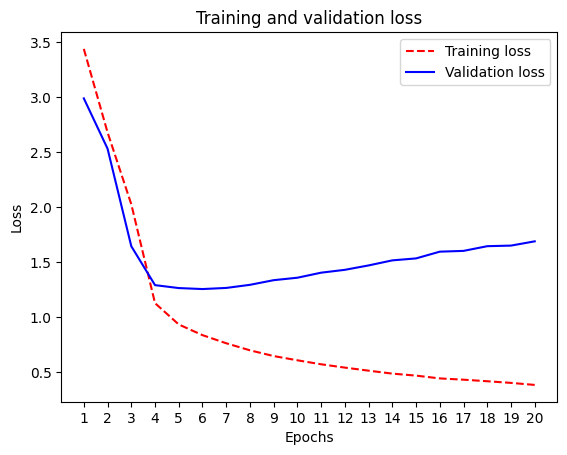

In [59]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

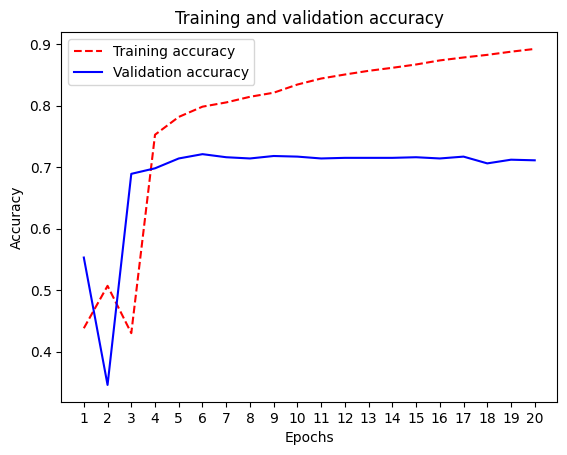

In [61]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Wrapping up

- If you're trying to classify data points among N classes, your model should end with a Dense layer of size N.

- In a single-label, multiclass classification problem, your model should end with a softmax activation so that it will output a probability distribution over the N output classes.

- Categorical crossentropy is almost always the loss function you should use for such problems. It minimizes the distance between the probability distributions output by the model and the true distribution of the targets.

- There are two ways to handle labels in multiclass classification:
  - Encoding the labels via categorical encoding (also known as one-hot encoding) and using categorical_crossentropy as a loss function

  - Encoding the labels as integers and using the sparse_categorical_crossentropy loss function

- If you need to classify data into a large number of categories, you should avoid creating information bottlenecks in your model due to intermediate layers that are too small.

### Predicting house prices: A regression example

The two previous examples were considered classification problems, where the goal was to predict a single discrete label of an input data point.
Another common type of machine learning problem is regression, which consists of predicting a continuous value instead of a discrete label: for instance, predicting the temperature tomorrow given meteorological data, or predicting the time that a software project will take to complete given its specifications.

Note that logistic regression isn't a regression algorithm — it's a classification algorithm.

#### The California Housing Price dataset

You'll attempt to predict the median price of homes in different areas of California, based on data from the 1990 census.

Each data point in the dataset represents information about a “block group,” a group of homes located in the same area. You can think of it as a district. This dataset has two versions, the “small” version with just 600 districts, and the “large” version with 20,640 districts. Let's use the small version, because real-world datasets can often be tiny, and you need to know how to handle such cases.

For each district, we know

- The longitude and latitude of the approximate geographic center of the area.

- The median age of houses in the district.

- The population of the district. The average population is 1,425.5.

- The total number of households.

- The median income of those households.

- The total number of rooms in the district, across all homes located there.

- The total number of bedrooms in the district.

The goal is to use these variables to predict the median value of the houses in the district.

In [62]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [63]:
train_data.shape

(480, 8)

In [64]:
test_data.shape

(120, 8)

In [65]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

It would be problematic to feed into a neural network values that all take wildly different ranges.
The model might be able to automatically adapt to such heterogeneous data, but it would definitely make learning more difficult.

A widespread best practice to deal with such data is to do feature-wise normalization: for each feature in the input data (a column in the input data matrix), you subtract the mean of the feature and divide by the standard deviation, so that the feature is centered around 0 and has a unit standard deviation.

In [66]:
# calculate mean of train_data along axis=0
mean = train_data.mean(axis=0)
# calculate std of train_data along axis=0
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In addition, we should also scale the targets.
Our normalized inputs have their value in a small range close to 0, and our model's weights are initialized with small random values.
This means that our model's prediction will also be small values when we start training.
If the targets are in the range 60,000-500,000, the model is going to need very large weight values to output those.
With a small learning rate, it would take a very long time to get there.
The simplest fix is to divide all target values by 100,000, so that the smallest target becomes 0.6, and the largest becomes 5.
We can then convert the model's predictions back to dollar values by multiplying them by 100,000 accordingly.

In [67]:
y_train = train_targets / 100000
y_test = test_targets / 100000

#### Building your model

In general, the less training data you have, the worse overfitting will be, and using a small model is one way to mitigate overfitting

The model ends with a single unit and no activation: it will be a linear layer. This is a typical setup for scalar regression — a regression where you're trying to predict a single continuous value.
Applying an activation function would constrain the range the output can take; for instance, if you applied a sigmoid activation function to the last layer, the model could only learn to predict values between 0 and 1.
Here, because the last layer is purely linear, the model is free to learn to predict values in any range.

In [68]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

#### Validating your approach using K-fold validation

The best practice when we have a small dataset is to use K-fold cross-validation.
It consists of splitting the available data into K partitions (typically K = 4 or 5), instantiating K identical models, and training each one on K - 1 partitions while evaluating on the remaining partition.
The validation score for the model used is then the average of the K validation scores obtained.

In [69]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    # get the model
    model = get_model()
    # fit with appropriate arguments for x,y-train , epochs
    # define batch_size=16, verbose=0
    model.fit(
        fold_x_train, fold_y_train, epochs=num_epochs, batch_size=16, verbose=0
    )
    # evaluate model with verbose=0
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    # unwrap scores into val_loss and val_mse
    val_loss, val_mse = scores[0], scores[1]
    all_scores.append(val_mse)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [70]:
[round(value, 3) for value in all_scores]

[0.309, 0.288, 0.259, 0.304]

In [71]:
round(np.mean(all_scores), 3)

np.float64(0.29)

The different runs show meaningfully different validation scores.
The average is a much more reliable metric than any single score — that's the entire point of K-fold cross-validation.
In this case, you're off by \$29,400 on average, which is significant considering that the prices range from \$60,000 to \$500,000.

---
Let's try training the model for 200 epochs.
To keep a record of how well the model does at each epoch, you'll modify the training loop to save the per-epoch validation score log.

In [73]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    # get the 'val_mean_absolute_error" value from history object
    mae_history = history.history['val_mean_absolute_error']
    # append mae_history to all_mae_histories
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [75]:
# compute the average of the per-epoch mean absolute error (MAE)
# scores for all folds
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

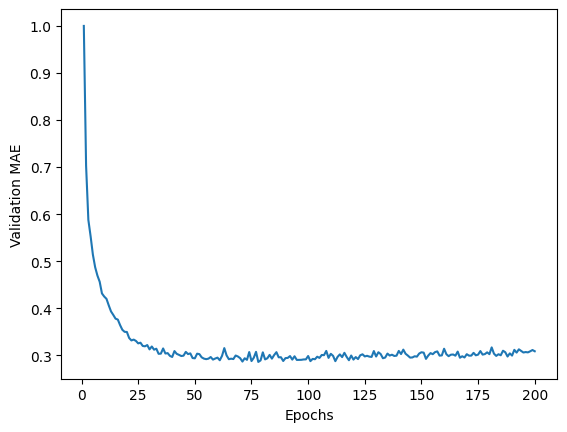

In [76]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

It may be a little difficult to read the plot due to a scaling issue: the validation MAE for the first few epochs is dramatically higher than the values that follow.
Let's omit the first 10 data points, which are on a different scale than the rest of the curve.

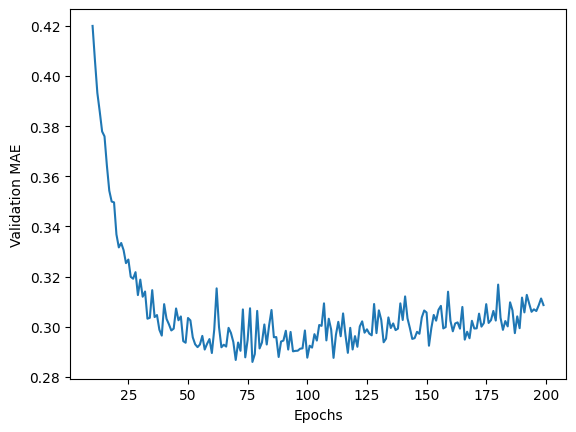

In [77]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

Validation MAE stops improving significantly after 120-140 epochs (this number includes the 10 epochs we omitted). Past that point, you start overfitting.

In [78]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2928 - mean_absolute_error: 0.3111


In [79]:
round(test_mean_absolute_error, 3)

0.311

#### Generating predictions on new data

With this scalar regression model, predict() returns the model's guess for the sample's price in hundreds of thousands of dollars:

In [80]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([2.400404], dtype=float32)

#### Wrapping up

- Regression is done using a different loss function than what we used for classification. Mean squared error (MSE) is a loss function commonly used for regression.

- Similarly, evaluation metrics to be used for regression differ from those used for classification; naturally, the concept of accuracy doesn't apply for regression. A common regression metric is MAE.

- When features in the input data have values in different ranges, each feature should be scaled independently as a preprocessing step.

- When there is little data available, using K-fold validation is a great way to reliably evaluate a model.

- When little training data is available, it's preferable to use a small model with few intermediate layers (typically only one or two), in order to avoid severe overfitting.